# WaveNet - skalowanie skip connections

Eksperyment porównuje wpływ parametru skip_connection_scale na trening i generację WaveNet. Wszystkie warianty były trenowane przez 1000 kroków na tej samej architekturze i danych. Różniła się tylko skala skip connections.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import soundfile as sf
from IPython.display import Audio, display

ROOT = Path('..').resolve()
AUDIO_DIR = ROOT / 'demo_outputs' / 'skip_connections'
AUDIO_FILES = {
    'skip_1_0': AUDIO_DIR / 'skip_1_0_generated.wav',
    'skip_0_5': AUDIO_DIR / 'skip_0_5_generated.wav',
}

AUDIO_DIR

WindowsPath('C:/Users/Lenovo/Desktop/ADOMProjekt/demo_outputs/skip_connections')

## Wyniki liczbowe

Główną metryką treningową był końcowy loss po 1000 krokach. Niższa wartość oznacza lepsze dopasowanie rozkładu kolejnej próbki audio.

In [7]:
results = pd.DataFrame([
    {'variant': 'skip_1_0', 'skip_connection_scale': '1.0', 'final_loss': 2.698, 'comment': 'baseline, najlepszy loss'},
    {'variant': 'skip_layer_decay', 'skip_connection_scale': '1.0 -> 0.25', 'final_loss': 3.082, 'comment': 'drugi najlepszy wynik'},
    {'variant': 'skip_0_5', 'skip_connection_scale': '0.5', 'final_loss': 3.740, 'comment': ''},
    {'variant': 'skip_norm_sqrt', 'skip_connection_scale': '0.25', 'final_loss': 4.344, 'comment': 'najmocniej przytlumione'},
])

results

,variant,skip_connection_scale,final_loss,comment
0,skip_1_0,1.0,2.698,"baseline, najlepszy loss"
1,skip_layer_decay,1.0 -> 0.25,3.082,drugi najlepszy wynik
2,skip_0_5,0.5,3.740,
3,skip_norm_sqrt,0.25,4.344,najmocniej przytlumione


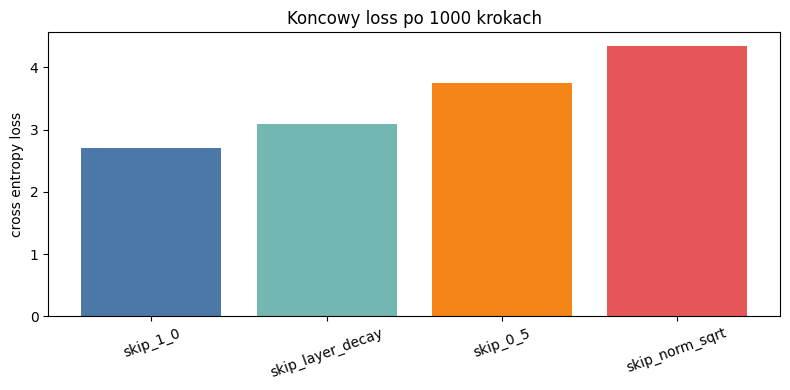

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(results['variant'], results['final_loss'], color=['#4C78A8', '#72B7B2', '#F58518', '#E45756'])
ax.set_title('Koncowy loss po 1000 krokach')
ax.set_ylabel('cross entropy loss')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()

## Próbki audio

Do prezentacji wybrano dwa najbardziej kontrastowe warianty odsłuchowo: baseline `skip_1_0` oraz `skip_0_5`, w którym szum był subiektywnie ostrzejszy.

In [9]:
for variant, path in AUDIO_FILES.items():
    audio, sample_rate = sf.read(path)
    print(f'{variant}: {path.name}, {len(audio) / sample_rate:.2f} s, {sample_rate} Hz')
    display(Audio(audio, rate=sample_rate))

skip_1_0: skip_1_0_generated.wav, 0.53 s, 16000 Hz


skip_0_5: skip_0_5_generated.wav, 0.53 s, 16000 Hz


## Spektrogramy

Na spektrogramie oś X to czas, oś Y to częstotliwość, a kolor oznacza energię. Jasne pionowe pasma oznaczają krótkie impulsy energii w szerokim zakresie częstotliwości. W odsłuchu odpowiadają zwykle trzaskom albo ostrzejszemu szumowi.

c:\Users\Lenovo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\matplotlib\axes\_axes.py:8283: RuntimeWarning: divide by zero encountered in log10
  Z = 10. * np.log10(spec)


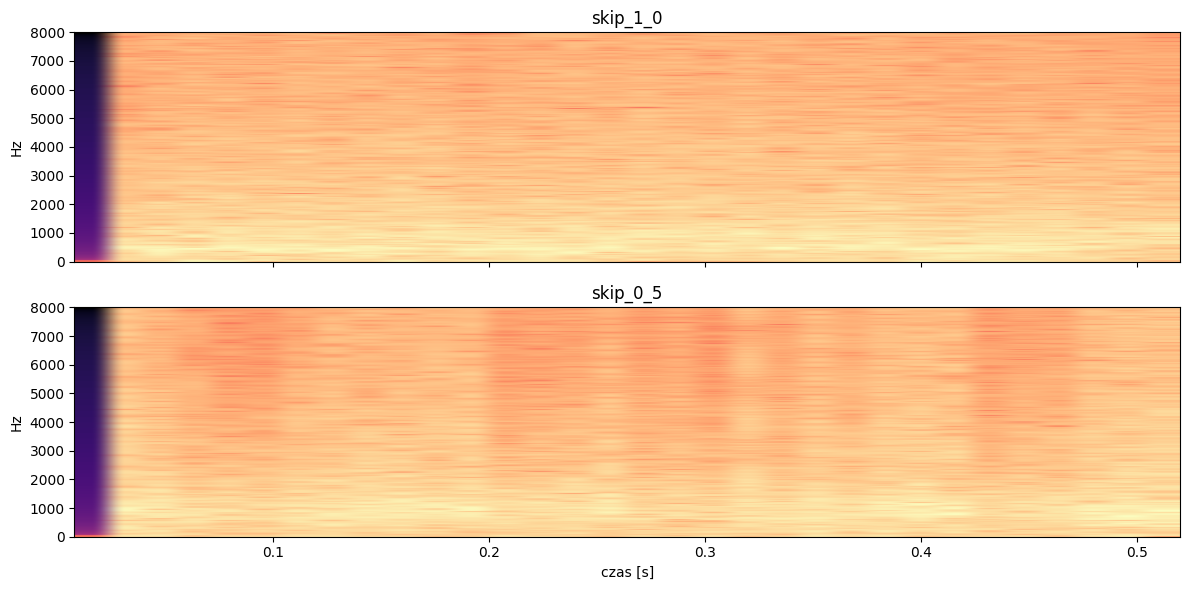

In [5]:
fig, axes = plt.subplots(len(AUDIO_FILES), 1, figsize=(12, 6), sharex=True)
for ax, (variant, path) in zip(axes, AUDIO_FILES.items()):
    audio, sample_rate = sf.read(path)
    ax.specgram(audio, Fs=sample_rate, NFFT=512, noverlap=256, cmap='magma')
    ax.set_title(variant)
    ax.set_ylabel('Hz')
axes[-1].set_xlabel('czas [s]')
plt.tight_layout()